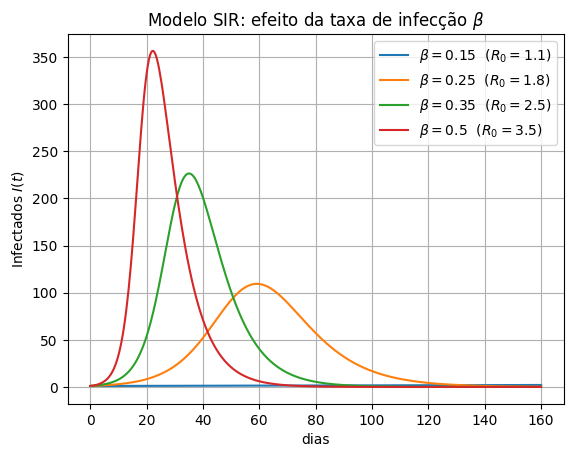

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def sir(y, t, beta, gamma, N):
    S, I, R = y
    dS = -beta*S*I/N
    dI = beta*S*I/N - gamma*I
    dR = gamma*I
    return [dS, dI, dR]

N = 1000
I0, R0_ = 1, 0
S0 = N - I0 - R0_
t = np.linspace(0, 160, 400)
gamma = 1/7  # ~7 dias até a recuperação

betas = [0.15, 0.25, 0.35, 0.5]
for beta in betas:
    sol = odeint(sir, [S0, I0, R0_], t, args=(beta, gamma, N))
    I = sol[:, 1]
    plt.plot(t, I, label=fr"$\beta={beta}$  ($R_0={beta/gamma:.1f}$)")

plt.xlabel("dias"); plt.ylabel("Infectados $I(t)$")
plt.title(r"Modelo SIR: efeito da taxa de infecção $\beta$")
plt.legend()
plt.grid(True)
plt.show()

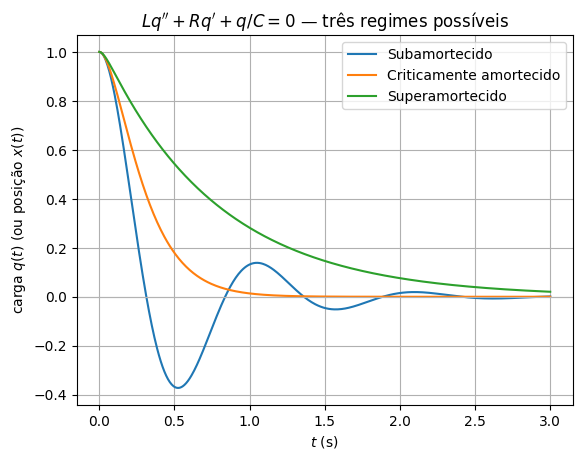

In [2]:
def osc(y, t, c, k, m=1):
    x, v = y
    return [v, -(c/m)*v - (k/m)*x]

m = 1
k = (2*np.pi)**2
c_crit = 2*np.sqrt(k*m)
t = np.linspace(0, 3, 500)

for label, c in [("Subamortecido", 0.3*c_crit),
                  ("Criticamente amortecido", c_crit),
                  ("Superamortecido", 2.5*c_crit)]:
    sol = odeint(osc, [1, 0], t, args=(c, k))
    plt.plot(t, sol[:, 0], label=label)

plt.axhline(0, color="0.7", linewidth=0.8)
plt.xlabel("$t$ (s)"); plt.ylabel(r"carga $q(t)$ (ou posição $x(t)$)")
plt.title(r"$L q'' + Rq' + q/C = 0$ — três regimes possíveis")
plt.legend()
plt.grid(True)
plt.show()

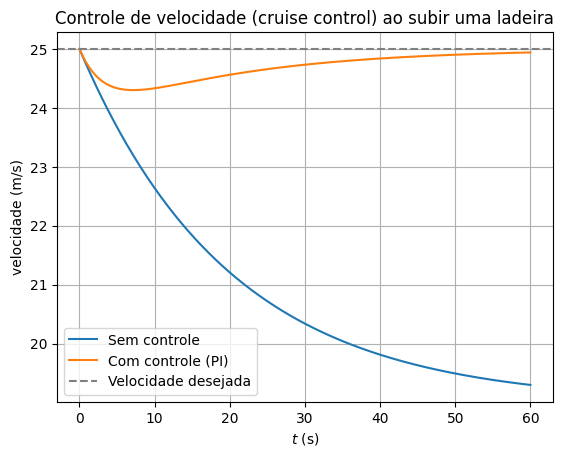

In [3]:
def cruise(y, t, b, m, F0, F_hill, kp, ki, v_ref, controlled):
    v, integral = y
    u = kp*(v_ref - v) + ki*integral if controlled else 0.0
    dv = (F0 + u - b*v - F_hill)/m
    dintegral = v_ref - v
    return [dv, dintegral]

m, b = 1000, 50       # massa (kg), coeficiente de arrasto/atrito
v_ref = 25             # velocidade desejada (m/s)
F0 = b*v_ref           # empuxo do motor que mantém v_ref em plano
F_hill = 300           # força extra exigida por uma ladeira, a partir de t=0

t = np.linspace(0, 60, 400)
sol_livre = odeint(cruise, [v_ref, 0], t, args=(b, m, F0, F_hill, 0, 0, v_ref, False))
sol_pid   = odeint(cruise, [v_ref, 0], t, args=(b, m, F0, F_hill, 300, 15, v_ref, True))

plt.plot(t, sol_livre[:, 0], label="Sem controle")
plt.plot(t, sol_pid[:, 0], label="Com controle (PI)")
plt.axhline(v_ref, color="gray", linestyle="--", label="Velocidade desejada")
plt.xlabel("$t$ (s)"); plt.ylabel("velocidade (m/s)")
plt.title("Controle de velocidade (cruise control) ao subir uma ladeira")
plt.legend()
plt.grid(True)
plt.show()

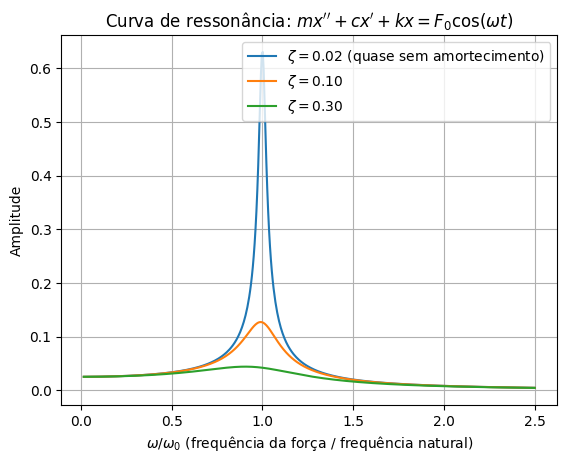

In [4]:
m, k = 1, (2*np.pi)**2
omega0 = np.sqrt(k/m)
omega = np.linspace(0.1, 2.5*omega0, 500)
F0 = 1

for zeta, label in [(0.02, r"$\zeta=0.02$ (quase sem amortecimento)"),
                      (0.10, r"$\zeta=0.10$"),
                      (0.30, r"$\zeta=0.30$")]:
    c = zeta*2*np.sqrt(k*m)
    amp = F0/np.sqrt((k - m*omega**2)**2 + (c*omega)**2)
    plt.plot(omega/omega0, amp, label=label)

plt.xlabel(r"$\omega/\omega_0$ (frequência da força / frequência natural)")
plt.ylabel("Amplitude")
plt.title(r"Curva de ressonância: $mx'' + cx' + kx = F_0\cos(\omega t)$")
plt.legend()
plt.grid(True)
plt.show()